In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
    
    
from src.config import PROCESSED_DATA_DIR
from src.utils.plots import save_figure, style_plot, create_figure
import pandas as pd


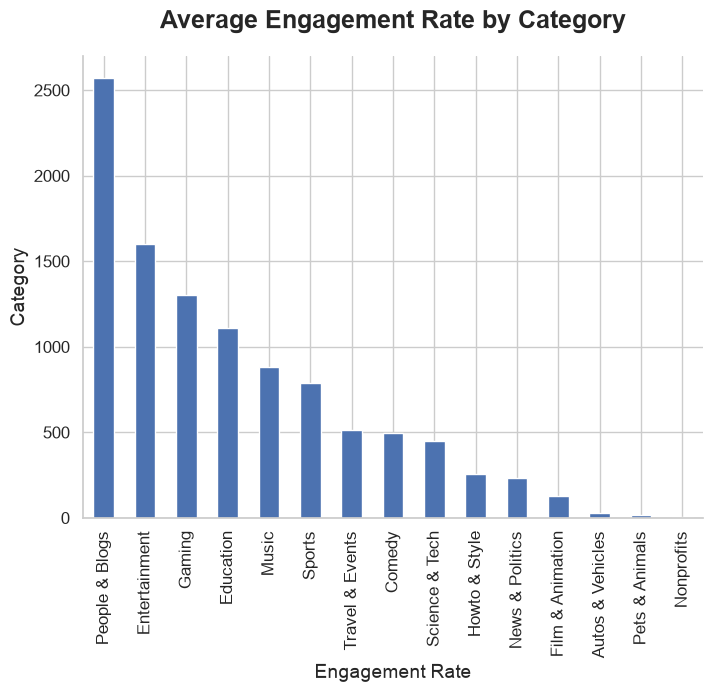

<Figure size 640x480 with 0 Axes>

In [2]:
df = pd.read_csv(PROCESSED_DATA_DIR / "youtube_clean.csv")


# category distribution
category_counts = (
    df["category_name"]
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = create_figure()
style_plot(ax)
category_counts.plot(kind="bar")
style_plot(
    ax,
    title="Average Engagement Rate by Category",
    xlabel="Engagement Rate",
    ylabel="Category"
)
plt.show()
plt.clf()


In [3]:
# category performance
category_summary = (
    df.groupby("category_name")
    .agg(
        videos=("video_id", "count"),
        mean_views=("views", "mean"),
        median_views=("views", "median"),
        mean_likes=("likes", "mean"),
        median_likes=("likes", "median"),
        mean_comments=("comments", "mean"),
        median_comments=("comments", "median"),
        mean_engagement=("engagement_rate", "mean"),
        median_engagement=("engagement_rate", "median")
    )
    .sort_values("mean_engagement", ascending=False)
)


category_summary

,videos,mean_views,median_views,mean_likes,median_likes,mean_comments,median_comments,mean_engagement,median_engagement
category_name,,,,,,,,,
Pets & Animals,17,2.786177e+07,4037087.0,618315.647059,49156.0,2390.882353,803.0,0.038660,0.025791
News & Politics,236,5.539686e+05,27104.5,8532.728814,513.0,571.940678,28.5,0.036090,0.016395
Gaming,1301,3.430537e+06,346263.0,65658.067640,7413.0,1751.748655,367.0,0.032684,0.025636
Science & Tech,447,8.548226e+06,1225839.0,197308.516779,22423.0,2307.872483,648.0,0.029340,0.026004
Nonprofits,7,6.512677e+06,344792.0,93689.285714,6016.0,360.142857,34.0,0.026771,0.016026
People & Blogs,2572,7.474335e+06,429408.0,114040.402411,5633.5,920.669518,68.0,0.025029,0.017242
Education,1110,8.621098e+06,393335.0,70070.704505,5424.0,1075.606306,54.0,0.024859,0.018912
Howto & Style,254,2.928521e+07,898319.5,388755.661417,15544.5,1304.708661,152.5,0.023078,0.016054
Travel & Events,514,2.845599e+06,496213.0,64235.747082,6213.5,936.776265,279.5,0.021901,0.016551


<Axes: ylabel='category_name'>

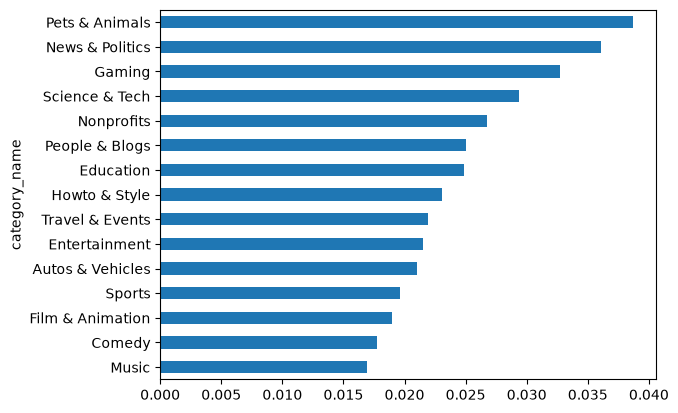

In [14]:
category_summary["mean_engagement"]\
    .sort_values()\
    .plot(kind="barh")

In [15]:
metrics = (
    df.groupby("category_name")
    .agg({
        "likes":"mean",
        "comments":"mean",
        "engagement_rate":"mean",
        "views":"mean"
    })
)

metrics.idxmax()

likes              Pets & Animals
comments                    Music
engagement_rate    Pets & Animals
views                       Music
dtype: str

<Axes: xlabel='engagement_rate', ylabel='category_name'>

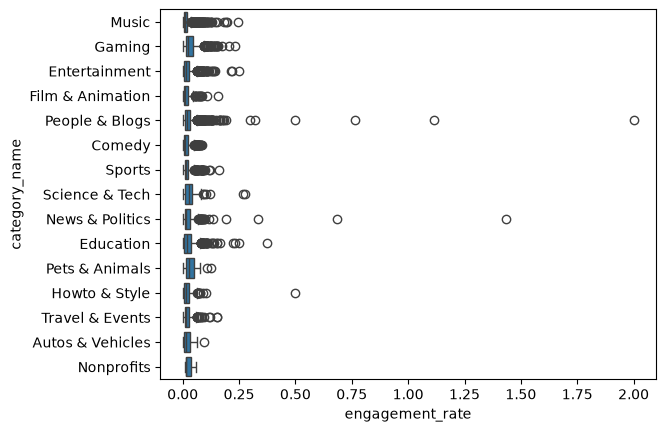

In [17]:
sns.boxplot(
    data=df,
    x="engagement_rate",
    y="category_name"
)